# **Identificación de grupos de hembras con perfiles reproductivos similares (Clustering)**

### **Por:**

*   Yasmin Judith Florez Zabala
*   John Jairo Sevilla Rodriguez
*   Yulexa Andrea Aragón Lemus

### **Ciclo de vida**
1. Preparación de Datos
3. Aprendizaje del Modelo: Kmeans
4. Evaluación del Modelo: Inercia y Silueta
5. Perfilamiento: Descripción de centroides


In [ ]:
# Se importan las librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

## **1. Preparación de Datos**

In [ ]:
# Se importa la librería para leer archivos .arff
from scipy.io import arff

# Se lee el archivo ARFF
data, meta = arff.loadarff('sabana_hembras_porcinas_procesado.arff')

# Se convierte a DataFrame
df_original = pd.DataFrame(data)

# Se decodifica todas las columnas de tipo objeto
for col in df_original.select_dtypes([object]).columns:
    df_original[col] = df_original[col].str.decode('utf-8')

# Se muestran las 5 primeras filas
df_original.head()

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS,PARTO_EXITOSO
0,6.0,14.000,2.0,0.0,EXITOSO
1,7.0,14.000,5.0,0.0,NO_EXITOSO
2,8.0,13.750,6.0,0.0,EXITOSO
3,9.0,14.000,6.0,0.0,NO_EXITOSO
4,10.0,13.666,6.0,0.0,EXITOSO


In [ ]:
# Selección de variables para clustering
df = df_original[['NUMERO_PARTO', 'PROMEDIO_VIVOS_ANTERIORES', 'TOTAL_MUERTOS_ANTERIORES', 'RETORNOS_ACUMULADOS']]
df.head()

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS
0,6.0,14.000,2.0,0.0
1,7.0,14.000,5.0,0.0
2,8.0,13.750,6.0,0.0
3,9.0,14.000,6.0,0.0
4,10.0,13.666,6.0,0.0


Para el análisis de clustering se utilizaron únicamente las variables predictoras previamente seleccionadas durante la etapa de modelado supervisado: **número de parto**, **promedio de vivos anteriores**, **total de muertos anteriores** y **retornos acumulados**. La variable **PARTO_EXITOSO** fue excluida debido a que corresponde a la variable objetivo del problema de clasificación y su inclusión podría sesgar la formación de los grupos, generando agrupamientos influenciados directamente por el resultado esperado. De esta manera, los clusters fueron construidos únicamente a partir de características reproductivas históricas de los registros.

In [ ]:
# Se conocen los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350981 entries, 0 to 350980
Data columns (total 4 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   NUMERO_PARTO               350981 non-null  float64
 1   PROMEDIO_VIVOS_ANTERIORES  350981 non-null  float64
 2   TOTAL_MUERTOS_ANTERIORES   350981 non-null  float64
 3   RETORNOS_ACUMULADOS        350981 non-null  float64
dtypes: float64(4)
memory usage: 10.7 MB


In [ ]:
# Descripción de los datos
df.describe()

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS
count,350981.000000,350981.000000,350981.000000,350981.000000
mean,4.562569,13.526068,2.135694,0.135620
std,2.354193,2.920242,2.644555,0.417706
min,2.000000,0.000000,0.000000,0.000000
25%,3.000000,12.000000,0.000000,0.000000
50%,4.000000,13.800000,1.000000,0.000000
75%,6.000000,15.500000,3.000000,0.000000
max,19.000000,31.000000,35.000000,9.000000


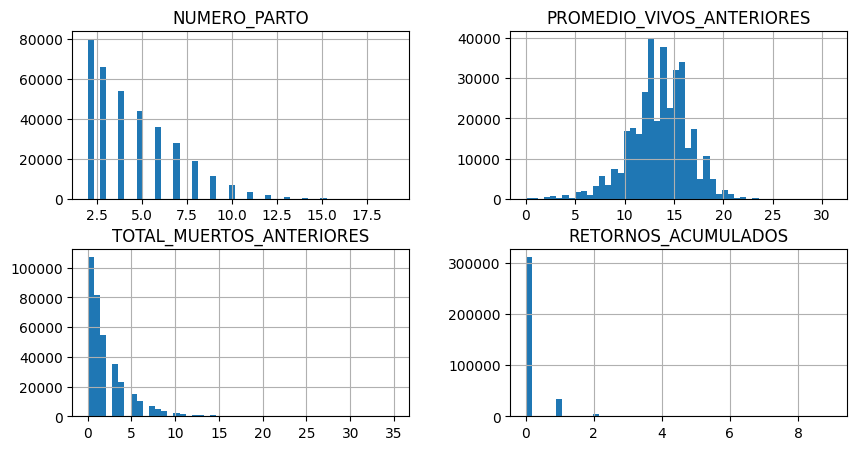

In [ ]:
# Histogramas de las variables numéricas
df.hist(bins=50, figsize=(10,5))
plt.show()

<Axes: >

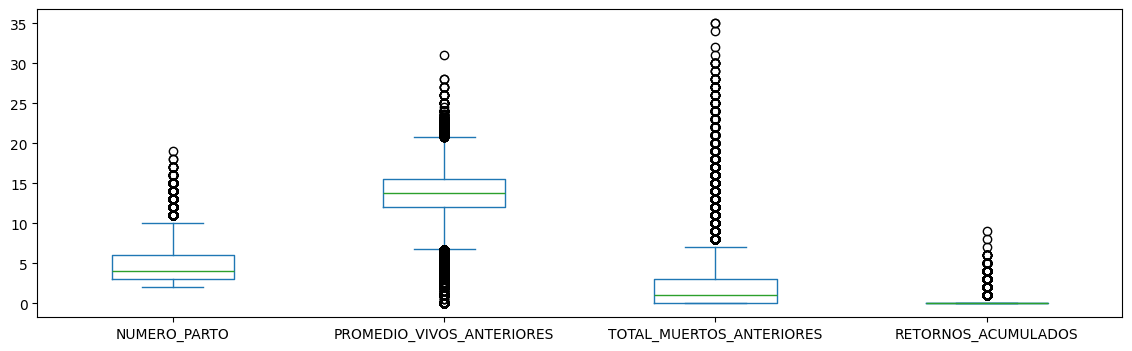

In [ ]:
# Descripción de las variables numéricas
df.plot(kind='box', figsize=(14, 4))

In [ ]:
# Se importa el escalador Min-Max para normalizar variables numéricas
from sklearn.preprocessing import MinMaxScaler

# Se crea el objeto escalador
min_max_scaler = MinMaxScaler()

# Lista de variables numéricas que serán normalizadas
variables_numericas = ["NUMERO_PARTO", "PROMEDIO_VIVOS_ANTERIORES", "TOTAL_MUERTOS_ANTERIORES", "RETORNOS_ACUMULADOS"]

# Se ajusta el escalador utilizando únicamente
# las variables numéricas seleccionadas
min_max_scaler.fit(df[variables_numericas])

# Se transforman las variables numéricas al rango [0,1]
# para que todas tengan una escala comparable
df[variables_numericas] = min_max_scaler.transform(df[variables_numericas])

# Se visualizan las primeras filas del DataFrame transformado
df.head()

/tmp/ipykernel_81612/1239476945.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[variables_numericas] = min_max_scaler.transform(df[variables_numericas])


,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS
0,0.235294,0.451613,0.057143,0.0
1,0.294118,0.451613,0.142857,0.0
2,0.352941,0.443548,0.171429,0.0
3,0.411765,0.451613,0.171429,0.0
4,0.470588,0.440839,0.171429,0.0


## **2. Aprendizaje del Modelo: Kmeans**

### **2.1. Método del Codo**

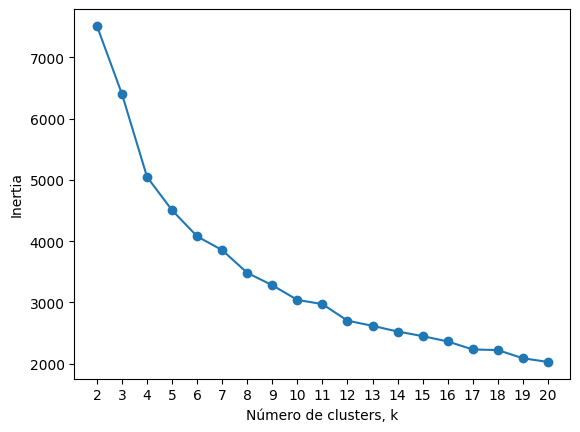

In [ ]:
# Método del codo para determinar la cantidad óptima de clusters
# utilizando la métrica inertia

# Se importa el modelo KMeans
from sklearn.cluster import KMeans

# Se define un rango de posibles cantidades de clusters
# desde 2 hasta 20
ks = range(2, 21)

# Lista donde se almacenarán los valores de inertia
inertias = []

# Se entrena un modelo KMeans para cada valor de k
for k in ks:
    # Crear el modelo KMeans
    # n_clusters=k -> número de grupos a formar
    # max_iter=300 -> máximo número de iteraciones permitidas
    model = KMeans(n_clusters=k, max_iter=300)

    # Entrenar el modelo con los datos
    model.fit(df)

    # Guardar el valor de inertia del modelo
    # inertia representa la suma de distancias cuadradas
    # entre cada punto y el centroide de su cluster
    inertias.append(model.inertia_)

# Graficar número de clusters vs inertia
# para identificar visualmente el "codo"
plt.plot(ks, inertias, '-o')

# Etiquetas de los ejes
plt.xlabel('Número de clusters, k')
plt.ylabel('Inertia')

# Mostrar todos los valores de k en el eje X
plt.xticks(ks)

# Mostrar gráfica
plt.show()

In [ ]:
# Se importa el algoritmo KMeans
from sklearn.cluster import KMeans

# Se define la cantidad de clusters seleccionada
# a partir del método del codo
k = 6

# Se crea el modelo KMeans
# n_clusters=k -> número de grupos a formar
# max_iter=300 -> máximo número de iteraciones permitidas
model = KMeans(n_clusters=k, max_iter=300)

# Se entrena el modelo utilizando el 100% de los datos
# para identificar agrupaciones con características similares
model.fit(df)

KMeans(n_clusters=6)

## **3. Evaluación del Modelo: Inercia y Silueta**

In [ ]:
# Se importa el módulo de métricas
from sklearn import metrics

# Inertia:
# Mide la cohesión interna de los clusters,
# es decir, qué tan cerca están los datos de su centroide.
# Valores más pequeños indican clusters más compactos.
print('Inercia o cohesión:', model.inertia_)

# Silhouette Score:
# Evalúa qué tan bien separados y definidos están los clusters.
# Su valor oscila entre -1 y 1.
# Valores cercanos a 1 indican mejor agrupamiento.
sil = metrics.silhouette_score(df, model.labels_)

# Mostrar resultado de la silueta
print('Silueta:', sil)

Inercia o cohesión: 4301.618575293745
Silueta: 0.24625683042702012


## **4. Perfilamiento**

In [ ]:
# Se visualizan los centroides generados por el modelo KMeans

# Cada fila representa el centro de un cluster
# y cada columna corresponde al valor promedio
# de una variable dentro de ese grupo
model.cluster_centers_

array([[2.25579158e-01, 4.53515350e-01, 8.04181746e-02, 5.02840473e-04],
       [4.58490332e-02, 5.36024331e-01, 2.83347637e-02, 6.61303419e-03],
       [6.93987608e-02, 2.68164706e-01, 3.65874048e-02, 9.67767182e-03],
       [4.10147591e-01, 4.15339028e-01, 1.41876889e-01, 1.56308232e-02],
       [5.23634327e-02, 4.16201195e-01, 3.22067280e-02, 5.62786214e-03],
       [1.92150908e-01, 4.21338609e-01, 8.09655281e-02, 1.47222734e-01]])

In [ ]:
# Los centroides de los clusters se convierten
# en un DataFrame de pandas para facilitar su análisis

centroides = pd.DataFrame(model.cluster_centers_, columns=df.columns.values)

# Se redondean los valores a una cifra decimal
# para mejorar la visualización e interpretación
centroides.round(1)

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS
0,0.2,0.5,0.1,0.0
1,0.0,0.5,0.0,0.0
2,0.1,0.3,0.0,0.0
3,0.4,0.4,0.1,0.0
4,0.1,0.4,0.0,0.0
5,0.2,0.4,0.1,0.1


In [ ]:
# Se realiza la desnormalización de las variables numéricas
# de los centroides para recuperar los valores originales

# inverse_transform permite regresar los datos
# desde la escala [0,1] a su escala real
centroides[variables_numericas] = (min_max_scaler.inverse_transform(centroides[variables_numericas]).round(0))
centroides

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS
0,6.0,14.0,3.0,0.0
1,3.0,17.0,1.0,0.0
2,3.0,8.0,1.0,0.0
3,9.0,13.0,5.0,0.0
4,3.0,13.0,1.0,0.0
5,5.0,13.0,3.0,1.0


In [ ]:
# En el DataFrame original se agrega una nueva columna con el cluster asignado a cada registro

# model.labels_ contiene el número de cluster al que pertenece cada observación
df['CLUSTER'] = model.labels_
df.head()

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS,CLUSTER
0,0.235294,0.451613,0.057143,0.0,0
1,0.294118,0.451613,0.142857,0.0,0
2,0.352941,0.443548,0.171429,0.0,3
3,0.411765,0.451613,0.171429,0.0,3
4,0.470588,0.440839,0.171429,0.0,3


<Axes: ylabel='count'>

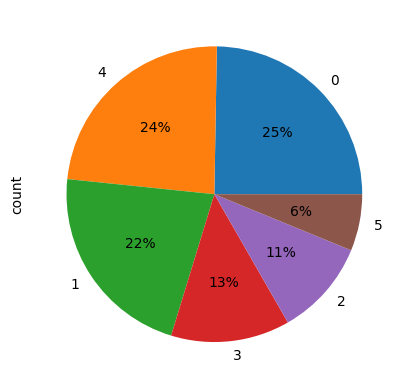

In [ ]:
#Cantidad de datos en cada cluster
df["CLUSTER"].value_counts().plot(kind='pie',autopct='%.0f%%')

In [ ]:
# Se agrega a los centroides la tasa de partos exitosos y la cantidad de registros pertenecientes a cada cluster

# TASA_EXITOSO_%:
# Calcula el porcentaje de registros clasificados como "EXITOSO" dentro de cada cluster
centroides['TASA_EXITOSO_%'] = (df_original.groupby(df['CLUSTER'])['PARTO_EXITOSO'].apply(lambda x: (x == 'EXITOSO').mean() * 100).round(1).values)

# N_REGISTROS:
# Calcula la cantidad de observaciones que pertenecen a cada cluster
centroides['N_REGISTROS'] = (df.groupby('CLUSTER').size().values)
centroides

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS,TASA_EXITOSO_%,N_REGISTROS
0,6.0,14.0,3.0,0.0,54.1,86787
1,3.0,17.0,1.0,0.0,68.6,76889
2,3.0,8.0,1.0,0.0,41.9,36924
3,9.0,13.0,5.0,0.0,33.8,45658
4,3.0,13.0,1.0,0.0,55.5,82981
5,5.0,13.0,3.0,1.0,45.8,21742
